In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from numpy.ma import masked_array
import os
import pandas as pd
import pickle
import copy
from scipy import stats

In [2]:
meta_df = pd.read_csv('analysis/data/movebank/Collective movement in wild baboons (data from Strandburg-Peshkin et al. 2015)-reference-data.csv')

In [3]:
days = sorted(os.listdir('analysis/data/xy/'))

presence = [[] for _ in range(meta_df.shape[0])]
for day in days:
    template = np.load('analysis/data/xy/%s'%day)
    for i,baboon in enumerate(template):
        presence[i].append(1 - sum(np.isnan(baboon.T[0]))/len(baboon.T[0]))
        
for i,baboon in enumerate(template):
    presence[i].append(0)
presence = np.array(presence)

In [4]:
# cdict = {'male - adult':'Blues','male - subadult':'Greens',
#          'female - adult':'Reds','female - subadult':'Oranges','female - juvenile':'Greys'}

tdict = {'male - adult':'a','male - subadult':'c',
         'female - adult':'b','female - subadult':'d','male - juvenile':'e'}

gdict = {'f':'female - ', 'm': 'male - '}

traits = [gdict[b]+c for a,b,c in meta_df[['animal-id','animal-sex','animal-life-stage']].sort_values(by='animal-id').values]



In [5]:
reorder = [x[0] for x in sorted(list(enumerate(presence.sum(axis=1))), key = lambda x: x[1])]

In [6]:
cdict = {'male - adult':'blue','male - subadult':'lightblue','male - juvenile':'green',
         'female - adult':'red','female - subadult':'lightorange'}

plt.rc('font', family='Helvetica')

combined_colors = {'purple':(40, 37, 70),'lightpurple':(84, 88, 116),
                   'blue':(84, 130, 154),'lightblue':(165, 188, 198),
                   'green':(66, 81, 45),'lightgreen':(164, 196, 99, ), # green: (120, 151, 59, )
                   'yellow':(244, 199, 72, ),'lightyellow':(245, 230, 98),
                   'orange':(230, 121, 62),'lightorange':(255,157,72),
                   'red':(135, 41, 43),'lightred':(185, 63, 63)
                   }
combined_colors = {c:np.array(v)/256 for c,v in combined_colors.items()}

In [7]:
reorder = [x[1] for x in sorted(zip(np.argmax(presence[reorder] == 0,axis=1),reorder))]

In [8]:
excludes = ['male - juvenile', 'male - subadult','female - subadult','male - adult','female - adult']

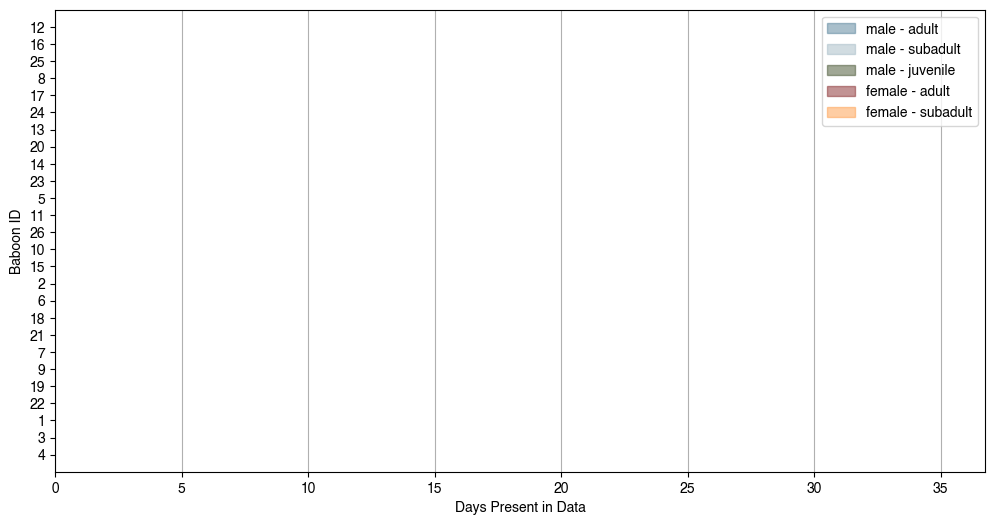

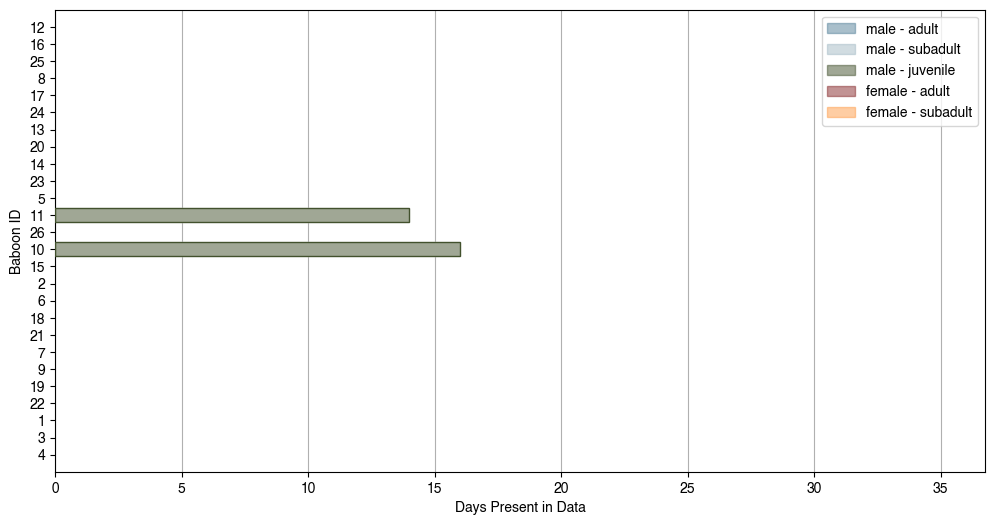

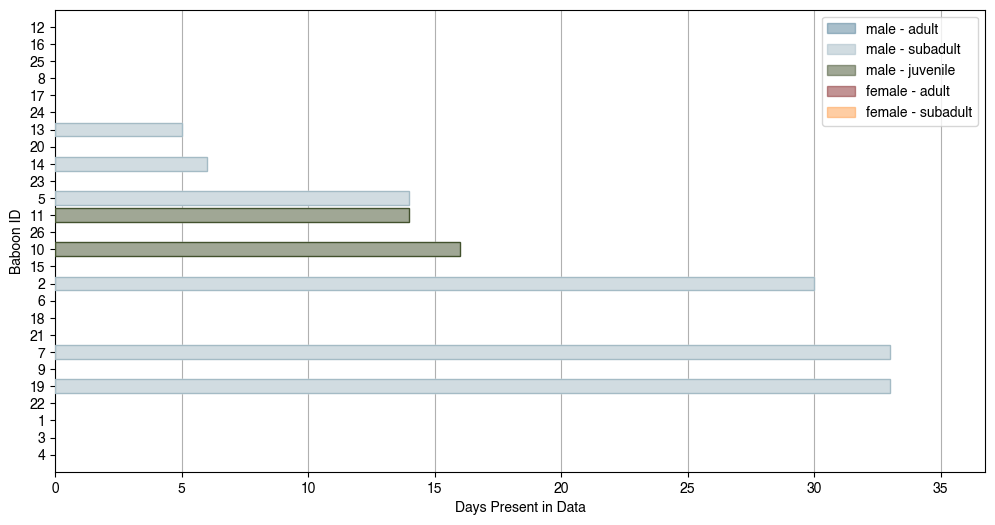

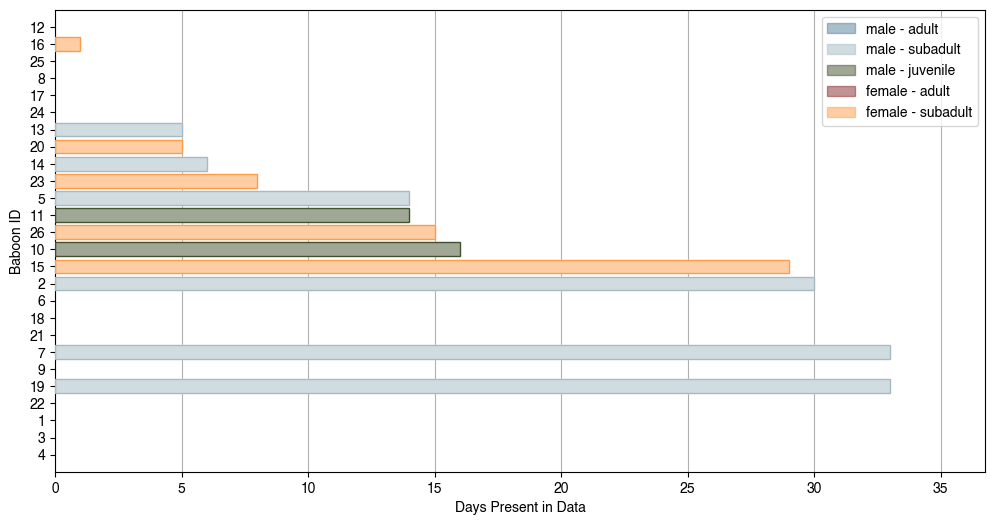

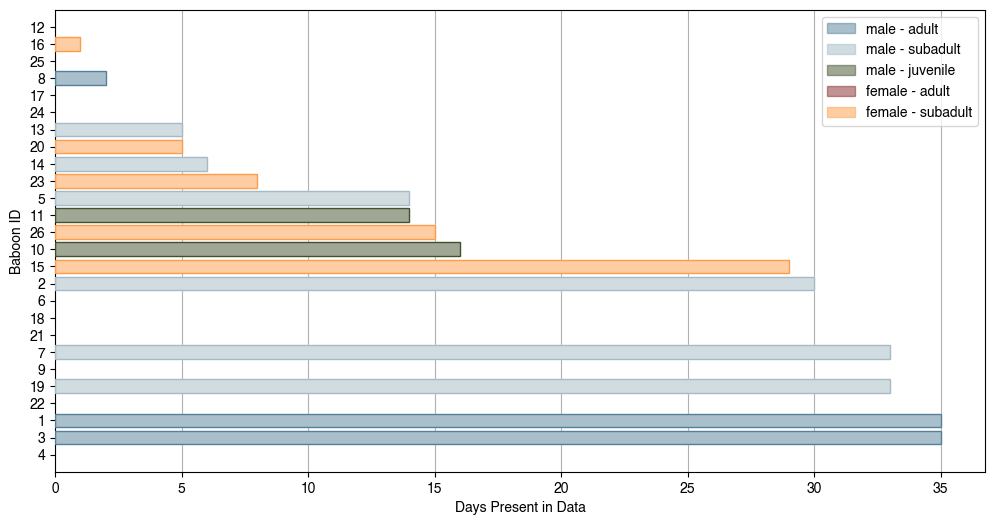

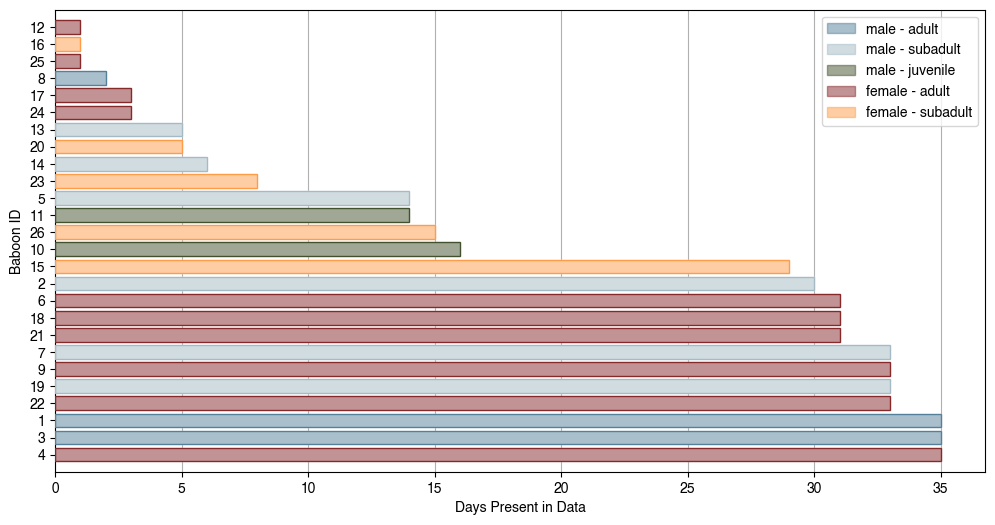

In [9]:
for number in range(6):
    fig, ax = plt.subplots(figsize=(12,6))
    labels = list(cdict.keys())
    ax.set_axisbelow(True)
    alpha = 1
    ax.set_axisbelow(True)
    ax.grid(axis='x',zorder=1)
    handles = [plt.Rectangle((0,0),1,1, color=tuple(combined_colors[cdict[t]])+tuple([alpha/2])) for t in labels]

    bars = ax.barh(np.arange(26)[::-1],np.argmax(presence[reorder] == 0,axis=1), 
             edgecolor = ['white' if t not in 
                     excludes[number:] else (0,0,0,0)
                          for t in np.array(traits)[reorder]],
            color = ['white' if t not in 
                     excludes[number:] else (0,0,0,0)
                          for t in np.array(traits)[reorder]],zorder=2)

    bars = ax.barh(np.arange(26)[::-1],np.argmax(presence[reorder] == 0,axis=1), 
             edgecolor = [combined_colors[cdict[t]] if t not in 
                     excludes[number:] else (0,0,0,0)
                          for t in np.array(traits)[reorder]],
            color = [tuple(combined_colors[cdict[t]])+tuple([alpha/2]) if t not in 
                     excludes[number:] else (0,0,0,0) for t in np.array(traits)[reorder]]
                   ,zorder=3)

    ax.legend(handles, labels)
    ax.set_xlabel('Days Present in Data')
    ax.set_yticks(np.arange(26)[::-1], np.array(reorder) + 1)
    ax.set_ylabel('Baboon ID')

    # for i in range(1,8):
    #     plt.plot([i*5,i*5], [-1,26],c='k')
    plt.ylim(-1,26)
    plt.savefig('figures/baboon_days_present_%d'%number)
    plt.show()

---

In [10]:
all_days = []
for day in days:
    template = np.load('analysis/data/xy/%s'%day)
    all_days.append(template)

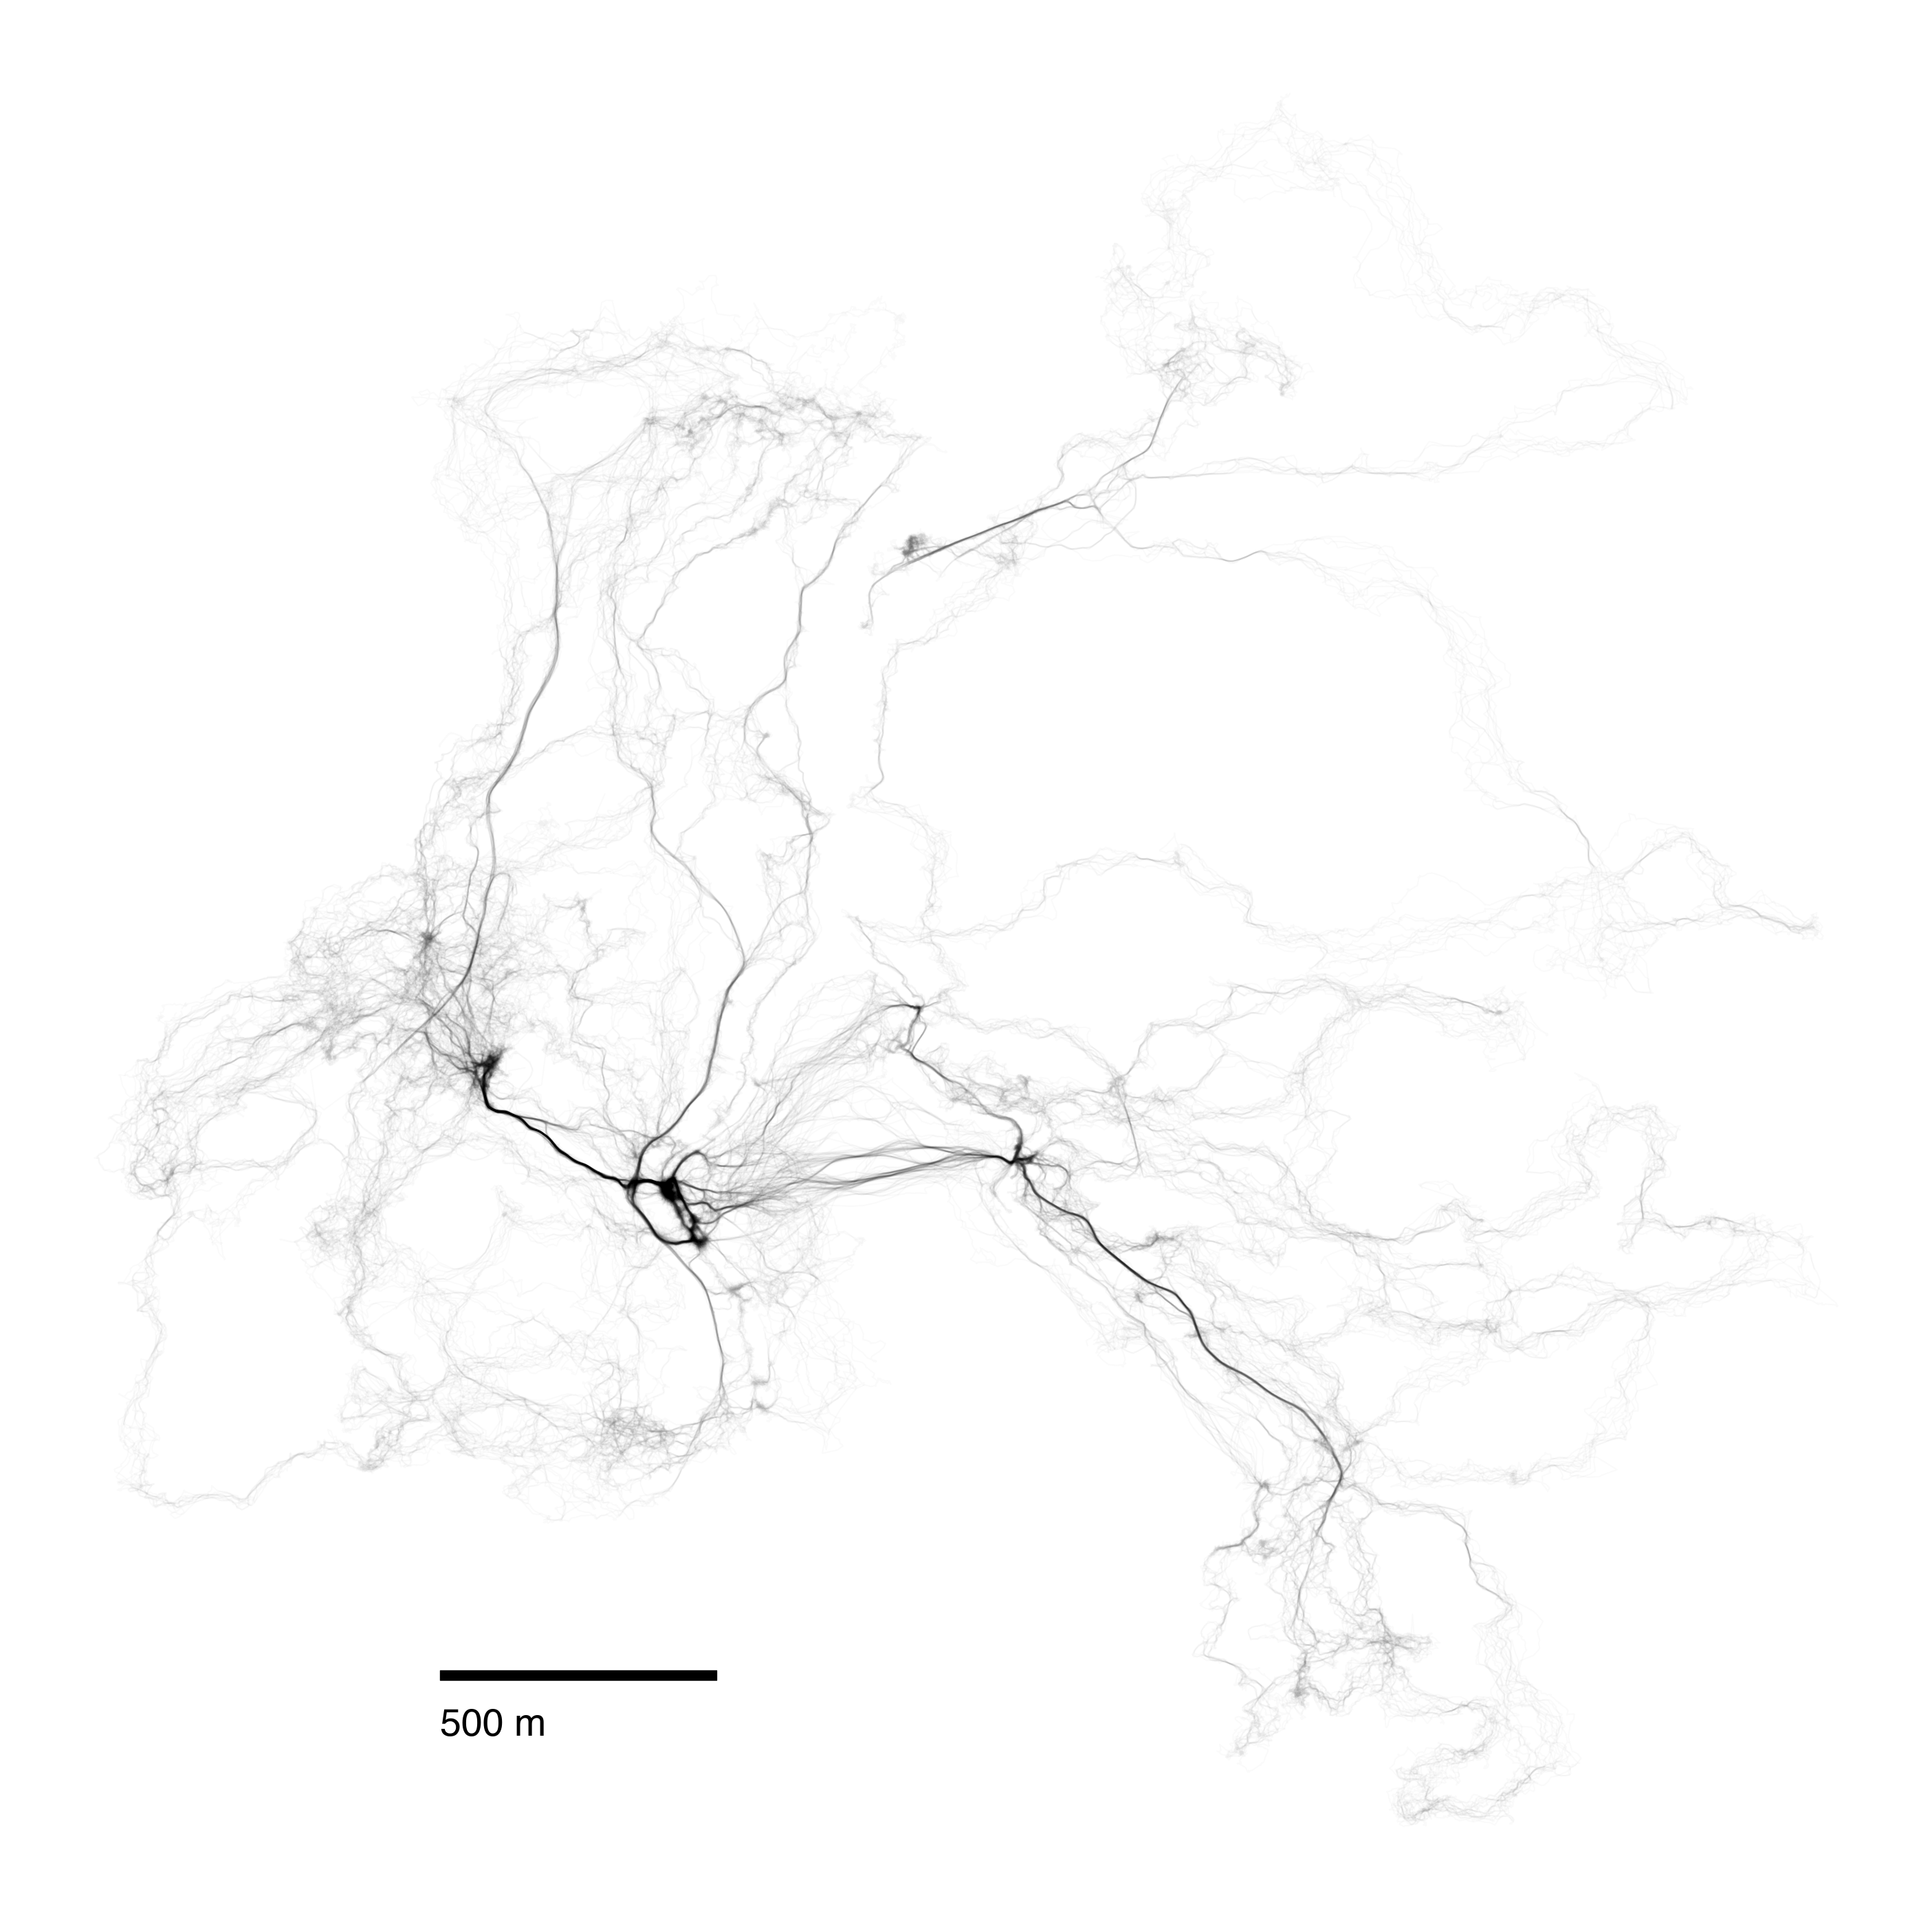

In [11]:
fig, ax = plt.subplots(figsize=(36,36))
for template in all_days:
    for t in template:
        ax.plot(*t[::20].T, c='k',alpha=.02);
        
plt.fill_between([-450,50],-1000,-1020,lw=1,color='k')
plt.annotate('500 m',(-450,-1140),fontsize=40,  ha='left')
ax.axis('off')
plt.savefig('figures/all_datapoints.png',facecolor='white',bbox_inches='tight',dpi=300)

---

In [12]:
sum([sum(~np.isnan(d.T[0].flatten())) for d in all_days])

np.int64(19206585)

---

In [13]:
import sys
sys.path.insert(1, 'analysis')
from hex_helpers import * # functions written in scripts/hex_helpers.py for working with hexagons
import matplotlib.patches as patches

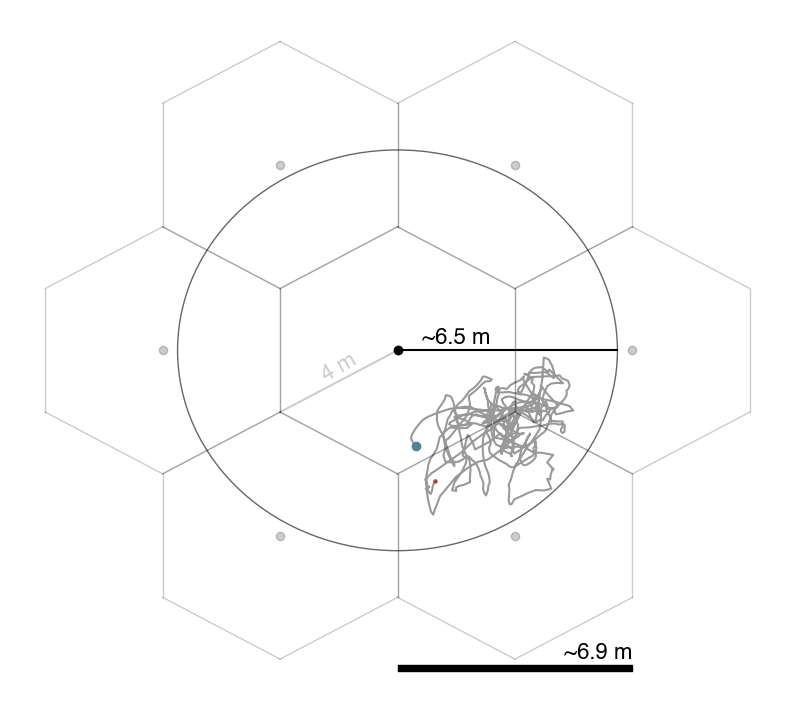

In [14]:
fig, axes = plt.subplots(1,1,figsize=(10,9))

hex_size = 4
event_radius = 1.622*hex_size
# # q,r = trajectory[0,1:3]
xx,yy = -.0,-22

for l,m in [(2,0),(1,-1),(-2,0),(-1,-1),(1,1),(-1,1),(0,0)]:
# # for x,y in [[x+hex_size*np.sqrt(3),y],
# #             [x+hex_size*np.sqrt(3)/2,y-1.5*hex_size],
# #             [x,y]]:
    x,y = xx + l*hex_size*np.sqrt(3)/2 , yy + m*1.5*hex_size
    for i in range(6):
        x1,y1 = hex_corner(x,y,hex_size,i)
        x2,y2 = hex_corner(x,y,hex_size,i+1)
        plt.plot([x1,x2],[y1,y2],c='k',lw=1,alpha=.2)
    plt.scatter(x,y, c='k',alpha=.2)

plt.scatter(xx,yy, c='k',alpha=1,zorder=4)
    
circ = patches.Circle((x,y), event_radius, alpha=0.6, ec='k',fill=False)

axes.add_patch(circ)

plt.scatter(*all_days[0][0][898].T,
            c=list([combined_colors['blue']]),zorder=3)
plt.plot(*all_days[0][0][898:1798+1].T, c='k',alpha=.4) # 1111 1798
plt.scatter(*all_days[0][0][1798].T,
            c=list([combined_colors['lightred']]),zorder=3,s=5)

plt.fill_between([0,hex_size*np.sqrt(3)],-32.2,-32.4,lw=1,color='k')
plt.annotate('~6.9 m',(hex_size*np.sqrt(3),-32.),fontsize=16,  ha='right')

# # plt.fill_between([- hex_size*np.sqrt(3) ,- hex_size*np.sqrt(3) + 4],-32.2,-32.4,lw=1,color='k')
# # plt.annotate('4 m',(- hex_size*np.sqrt(3),-32.),fontsize=16,  ha='left')

plt.plot([event_radius,0],[-22,-22],c='k')
plt.annotate('~6.5 m',(hex_size*np.sqrt(3)/4,-22+.2),fontsize=16,  ha='center',rotation=0)

plt.plot([- hex_size*np.sqrt(3)/2,0],[-22-hex_size/2,-22],alpha=.2,c='k')
plt.annotate('4 m',(- hex_size*np.sqrt(3)/4,-22-hex_size/4),fontsize=16,  ha='center',rotation=30,alpha=.2)

plt.axis('off')
    
# # plt.plot(*coarse_graining[1][1][:splits[1]+1][:,-2:].T)
plt.savefig('figures/milling_6.png',facecolor='white',bbox_inches='tight',dpi=150)
plt.show()

In [15]:
np.sqrt(sum(np.array((1*hex_size*np.sqrt(3)/2 , 1*1.5*hex_size))**2))

np.float64(6.928203230275509)

In [16]:
1.622*4,event_radius

(6.488, 6.488)

---

In [17]:
event_radii = pickle.load( open( "analysis/data/final_event_radii.p", "rb" ) )
est_radii = pickle.load( open( "analysis/data/estimated_event_radii.p", "rb" ) )

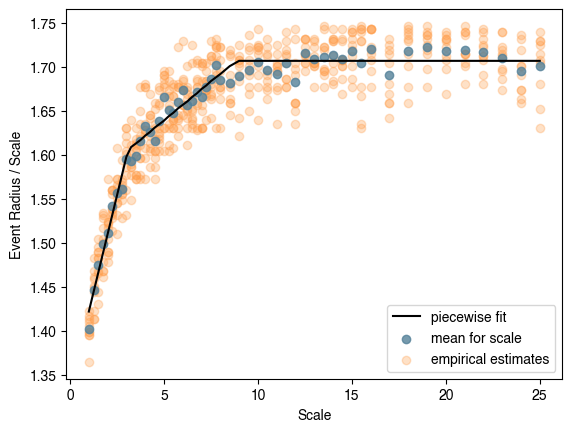

In [18]:
plt.plot(*np.array(list(event_radii.items())[:54]).T, c= 'k', label='piecewise fit',zorder=3)

for k,v in est_radii.items():
    if k == 25:
        plt.scatter(k,np.mean(v),c=[combined_colors['blue']],alpha=.8,zorder=2,label='mean for scale')
        plt.scatter([k for _ in v],v,c=[combined_colors['lightorange']],alpha=.3,label='empirical estimates')
    elif k < 25:
        plt.scatter(k,np.mean(v),c=[combined_colors['blue']],alpha=.8,zorder=2)
        plt.scatter([k for _ in v],v,c=[combined_colors['lightorange']],alpha=.3)
    else:
        continue
        
plt.xlabel('Scale')
plt.ylabel('Event Radius / Scale')
plt.legend()
plt.savefig('figures/radii_estimates_2.png',facecolor='white',bbox_inches='tight',dpi=150)
plt.show()

---

In [19]:
interactions = pd.read_csv('analysis/data/ari_single_interactions.csv')
interactions = copy.deepcopy(interactions.loc[interactions['day'] <= 14])

baboon_info = pd.read_csv('analysis/data/baboon_info.csv',index_col=0)

In [20]:
baboon_pull_ratios = {}
baboon_pull_anchor_counts = {}
for b in baboon_info.index:
    bdf = interactions.loc[interactions['leader'] == b]
    if len(bdf) > 0:
        interaction_counts = bdf['type'].value_counts()
        baboon_pull_ratios[b] = interaction_counts['pull'] / (sum(interaction_counts))
        baboon_pull_anchor_counts[b] = (interaction_counts['pull'],interaction_counts['anchor'],sum(interaction_counts))
    else:
        baboon_pull_ratios[b] = np.nan
        baboon_pull_anchor_counts[b] = np.nan

In [21]:
def plot_dominance(baboons,colors,extras = True,g='female'):
    _, ax = plt.subplots(figsize=(6,4))
    one_sa = False
    one_a = False
    one_g = False
    for x,b in enumerate(baboons):
        age = baboon_info.loc[b,'Age']
        if baboon_info.loc[21,'Days present'] < 10:
            col = 'black'
        if age == 'SA':
            plt.scatter(x+1,baboon_pull_ratios[b],s=200,label=g+" - subadult" if one_sa == False else None,
                        c=colors[0] if baboon_info.loc[b,'Days present'] >= 10 else 'grey')
            plt.annotate(b,(x+1,baboon_pull_ratios[b]-.015),ha="center",c="white",fontsize=10)
            one_sa = True
        elif age == 'A':
            if baboon_info.loc[b,'Days present'] >= 10:
                plt.scatter(x+1,baboon_pull_ratios[b],s=200,label=g+" - adult" if one_a == False else None,
                        c=colors[1] if baboon_info.loc[b,'Days present'] >= 10 else 'grey')
                one_a = True
            else:
                plt.scatter(x+1,baboon_pull_ratios[b],s=200,label="insufficient data" if one_g == False else None,
                        c=colors[1] if baboon_info.loc[b,'Days present'] >= 10 else 'grey')
                one_g = True
            plt.annotate(b,(x+1,baboon_pull_ratios[b]-.015),ha="center",c="white",fontsize=10)
        else:
            continue
    plt.ylim(0,1)
    plt.xlabel('Social Dominance Rank')
    plt.ylabel('')
    plt.legend(loc='lower right',labelspacing=1.2)
    if extras:
        plt.ylabel('Probability of being followed')
        plt.annotate('More Dominant', xy=(2, .9), xycoords='data',
                xytext=(0.6, .9), textcoords='axes fraction',
                va='center', ha='left',
                arrowprops=dict(facecolor='black'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

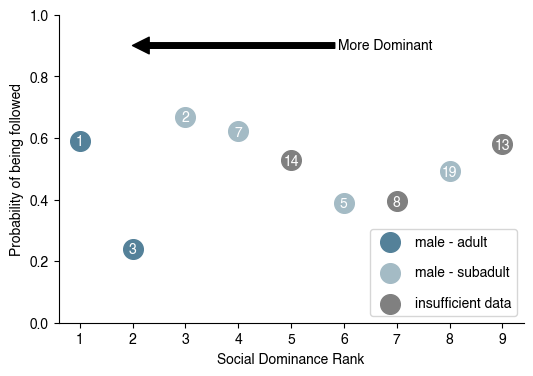

In [22]:
plot_dominance(baboon_info.loc[baboon_info['Sex'] == 'M'].sort_values(by='Dominance').index,
              [[combined_colors['lightblue']],
               [combined_colors['blue']],
               [combined_colors['yellow']]],g='male')
plt.savefig('figures/male_dominance.png',facecolor='white',bbox_inches='tight',dpi=150)
plt.show()

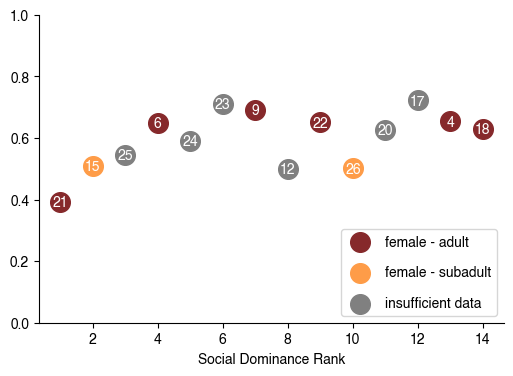

In [23]:
plot_dominance(baboon_info.loc[baboon_info['Sex'] == 'F'].sort_values(by='Dominance').index,
              [[combined_colors['lightorange']],
               [combined_colors['red']]], False)
plt.savefig('figures/female_dominance.png',facecolor='white',bbox_inches='tight',dpi=150)
plt.show()

In [24]:
m_ranks = list(sorted([[x[1][0],x[0]+1,x[1][1]] for x in list(enumerate(sorted([(b,i+1,baboon_pull_ratios[b]) for i,b in enumerate(baboon_info.loc[(baboon_info['Sex'] == 'M')&(baboon_info['Days present'] >= 10)].sort_values(by='Dominance').index) if b not in [10,11]],key = lambda x:x[2], reverse = True)))], key = lambda x:x[2]))
f_ranks = list(sorted([[x[1][0],x[0]+1,x[1][1]] for x in list(enumerate(sorted([(b,i+1,baboon_pull_ratios[b]) for i,b in enumerate(baboon_info.loc[(baboon_info['Sex'] == 'F')&(baboon_info['Days present'] >= 10)].sort_values(by='Dominance').index) if b not in [10,11]],key = lambda x:x[2], reverse = True)))], key = lambda x:x[2]))

In [25]:
stats.spearmanr(*np.array(f_ranks)[:,1:].T)

SignificanceResult(statistic=np.float64(-0.3571428571428572), pvalue=np.float64(0.3851206435562562))

In [26]:
def statistic(x):  # permute only `x`
    return stats.spearmanr(x, y).statistic

x,y = np.array(f_ranks)[:,1:].T

res_exact = stats.permutation_test((x,), statistic,
                                   permutation_type='pairings')
res_asymptotic = stats.spearmanr(x, y)
res_exact.pvalue, res_asymptotic.pvalue  # asymptotic pvalue is too low

(np.float64(0.386), np.float64(0.3851206435562562))

In [27]:
day_one_ints = interactions.loc[interactions['day'] == 1,['t1','leader','type']]

In [28]:
day_one_pnts = []
for v in day_one_ints.values:
    day_one_pnts.append(all_days[0][v[1] - 1][v[0]])

In [29]:
day_one_ints[['x','y']] = day_one_pnts

In [30]:
day_one_ints = day_one_ints.dropna()

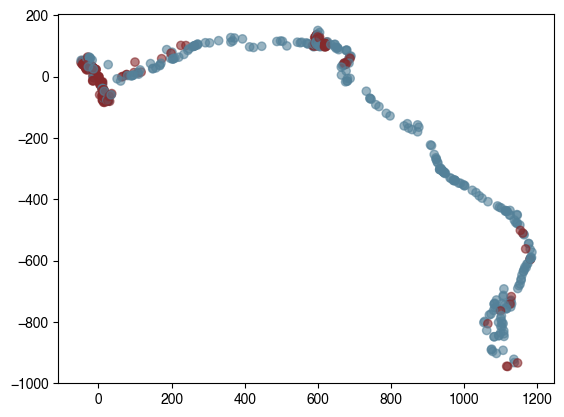

In [31]:
start_ints = day_one_ints.loc[day_one_ints['t1'] < 17000]
plt.scatter(*start_ints[['x','y']].values.T,alpha=.6,
            c=[combined_colors['blue'] if t == 'pull' else combined_colors['red'] for t in start_ints['type']]);

308 0.136
96 0.719
78 0.436
172 0.913


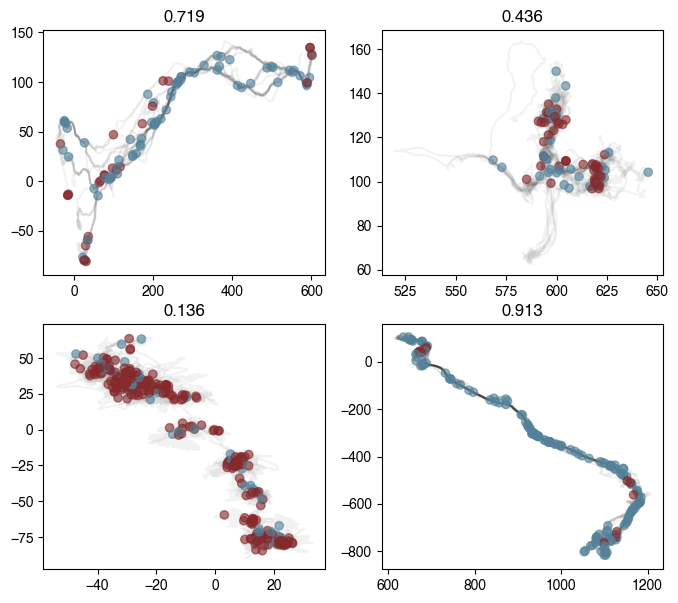

In [32]:
fig,axes = plt.subplots(2,2,figsize=(8,7))
for i,start,end in [[2,0,7500],[0,7500,8800],[1,8800,12000],[3,12000,16200]]:
    start_ints = day_one_ints.loc[(day_one_ints['t1'] >= start)&(day_one_ints['t1'] < end)]
    axes.flatten()[i].scatter(*start_ints[['x','y']].values.T,alpha=.6,
            c=[combined_colors['blue'] if t == 'pull' else combined_colors['red'] for t in start_ints['type']]);
    axes.flatten()[i].set_title(np.mean(start_ints['type'] == 'pull').round(3))
    print(len(start_ints),np.mean(start_ints['type'] == 'pull').round(3))
    for b in all_days[0]:
        axes.flatten()[i].plot(*b[start:end].T, c='k',alpha=.05,zorder=0)

In [33]:
0,7500
12000,17000

(16200-12000)/(60*60)

1.1666666666666667

In [34]:
7500/(60*60)
308+96+78+172

654

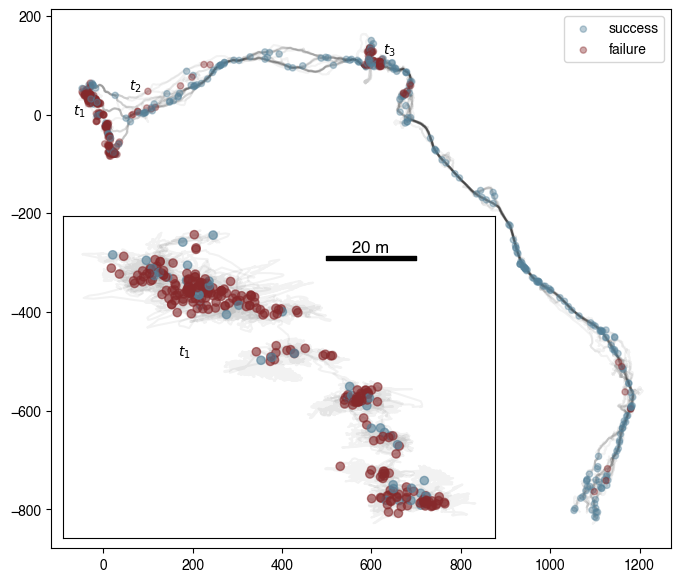

In [35]:
fig, ax1 = plt.subplots(figsize=(8,7))

for b in all_days[0]:
    ax1.plot(*b[0:16200].T, c='k',alpha=.05,zorder=0)
    
start_ints = day_one_ints.loc[(day_one_ints['t1'] >= 0)&(day_one_ints['t1'] < 16200)]
ax1.scatter(*start_ints[['x','y']].values[:10].T,alpha=.4,s=20,label="success",
            c=[combined_colors['blue'] if t == 'pull' else combined_colors['red'] for t in start_ints['type'].values[:10]]);
ax1.scatter(*start_ints[['x','y']].values[10:].T,alpha=.4,s=20,label="failure",
            c=[combined_colors['blue'] if t == 'pull' else combined_colors['red'] for t in start_ints['type'].values[10:]]);


# These are in unitless percentages of the figure size. (0,0 is bottom left)
left, bottom, width, height = [0.14, 0.125, 0.54, 0.46]
ax2 = fig.add_axes([left, bottom, width, height])


start_ints = day_one_ints.loc[(day_one_ints['t1'] >= 0)&(day_one_ints['t1'] < 7500)]
ax2.scatter(*start_ints[['x','y']].values.T,alpha=.6,
        c=[combined_colors['blue'] if t == 'pull' else combined_colors['red'] for t in start_ints['type']]);

for b in all_days[0]:
    ax2.plot(*b[0:7500].T, c='k',alpha=.05,zorder=0)
ax2.set_xticks([])
ax2.set_yticks([])

ax2.annotate("$t_{1}$",np.nanmean(all_days[0][:,7500] + np.array([-25,0]),axis=0),c='k')

ax1.annotate("$t_{1}$",np.nanmean(all_days[0][:,7500] + np.array([-60,0]),axis=0),c='k')
ax1.annotate("$t_{2}$",np.nanmean(all_days[0][:,8000] + np.array([0,40]),axis=0),c='k')
ax1.annotate("$t_{3}$",np.nanmean(all_days[0][:,12000] + np.array([0,20]),axis=0),c='k')
ax1.legend()

ax2.fill_between([0,20],50,52,lw=1,color='k')
ax2.annotate('20 m',(10,54),fontsize=12,  ha='center')

plt.savefig('figures/initlocs_1.png',facecolor='white',bbox_inches='tight',dpi=150)
plt.show()

In [36]:
start_ints['type'].value_counts()

type
anchor    266
pull       42
Name: count, dtype: int64

---

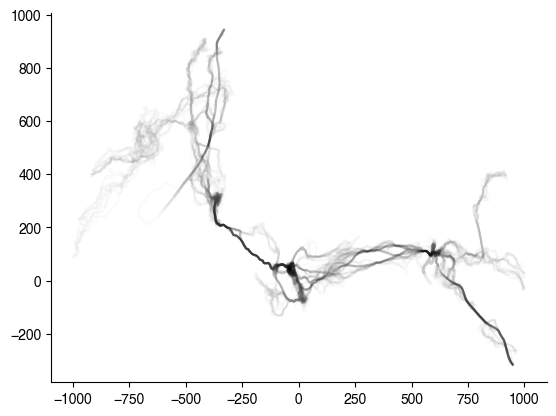

In [37]:
fig, ax = plt.subplots()
for number,d in enumerate(all_days[:14]):
    for b in d:
        limit = np.nanargmax(np.sqrt((b**2).sum(axis=1)) > 1000)
        ax.plot(*b[:limit].T, c='k', alpha=.02, zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('figures/rltrajectories.png',facecolor='white',bbox_inches='tight',dpi=300)

In [38]:
np.nanargmax((d[0]**2).sum(axis=1))

np.int64(20637)

---

43147
2276
992


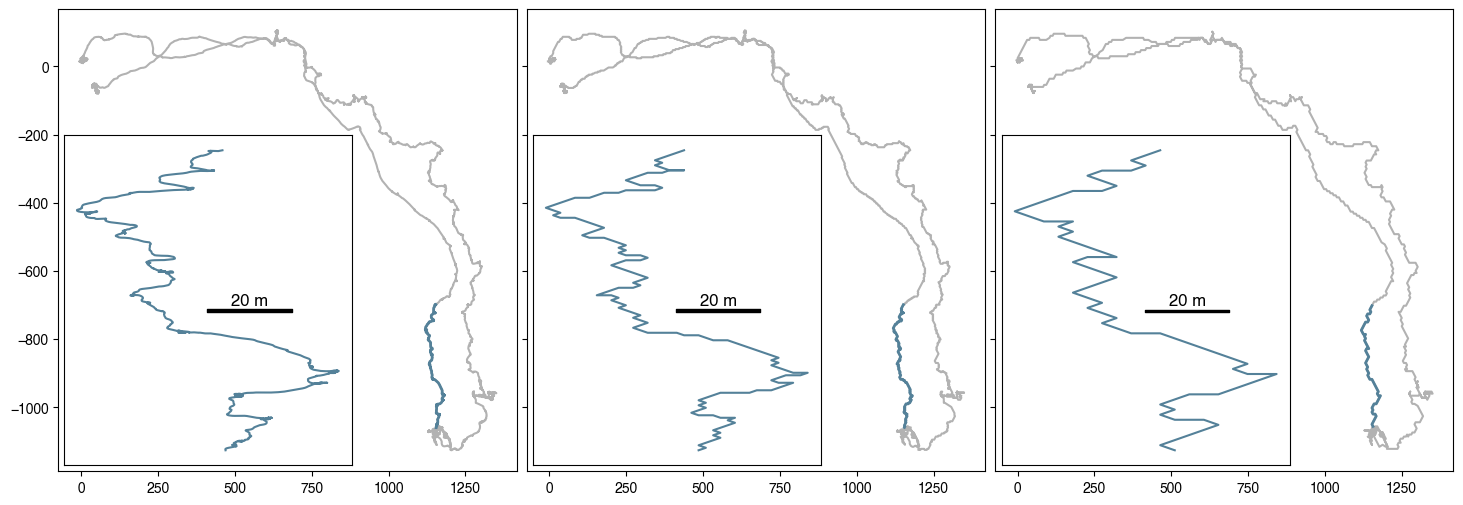

In [39]:
trajectories = pickle.load( open( "analysis/data/full_days.p", "rb" ) )

day = 1
baboon = 1

xy_traj = trajectories[day][baboon]

origin_id = 0

fig, ax = plt.subplots(1,3, figsize=(18,6),sharey=True, sharex=True)
ax.flatten()[0].plot(*np.array(xy_traj).T,c='k',alpha=.3)
ax.flatten()[0].plot(*np.array(xy_traj)[15500:18000].T,
                     c = combined_colors['blue'],lw=2)


left, bottom, width, height = [0.128, 0.12, 0.16, 0.55]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.plot(*np.array(xy_traj)[15500:18000].T,c = combined_colors['blue'])
ax1.set_xticks([])
ax1.set_yticks([])
ax1.fill_between([1150,1170],-890,-893,lw=1,color='k')
ax1.annotate('20 m',(1160,-885),fontsize=12,  ha='center')
print(len(xy_traj))


for i,hex_size in zip([1,2],[2,4]):

    event_times = pickle.load( open( "analysis/data/coarse_grainings/%.3f/%d.p"%(hex_size,origin_id), "rb" ) )

    splits = copy.deepcopy(event_times[day][baboon])

    hex_traj = xy_traj_to_qr_traj(xy_traj,hex_size)#.astype(int)
    
    ax.flatten()[i].plot(*np.array([qr_to_xy(q,r,hex_size) for q,r in hex_traj[splits]]).T,c='k',alpha=.3);
    ax.flatten()[i].plot(*np.array([qr_to_xy(q,r,hex_size) for q,r in hex_traj[splits[(splits >= 15500)*(splits < 18000)]]]).T,
                        c = combined_colors['blue'],lw=2)
    
    ax2 = fig.add_axes([left+.2605*i, bottom, width, height])
    ax2.plot(*np.array([qr_to_xy(q,r,hex_size) for q,r in hex_traj[splits[(splits >= 15500)*(splits < 18000)]]]).T,
                        c = combined_colors['blue'])
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.fill_between([1150,1170],-890,-893,lw=1,color='k')
    ax2.annotate('20 m',(1160,-885),fontsize=12,  ha='center')
    print(len(splits))
    
ax.flatten()[0].set_xticks([i*250 for i in range(6)] )
plt.subplots_adjust(wspace=.02, hspace=0)
plt.savefig('figures/cgtrajexample.png',facecolor='white',bbox_inches='tight',dpi=150)